|Dataset Name| Algorithm| Complated| Accuracy Score|
|   :---:    | :---:| :---: |:---:|
| Diabetes Dataset|  Linear Regression | No | 42.90|

In [767]:
from sklearn.datasets import load_diabetes
import pandas as pd 

In [768]:
data = load_diabetes()
df = pd.DataFrame(columns=data.feature_names,data=data.data)
df["target"] = data.target

In [769]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [770]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


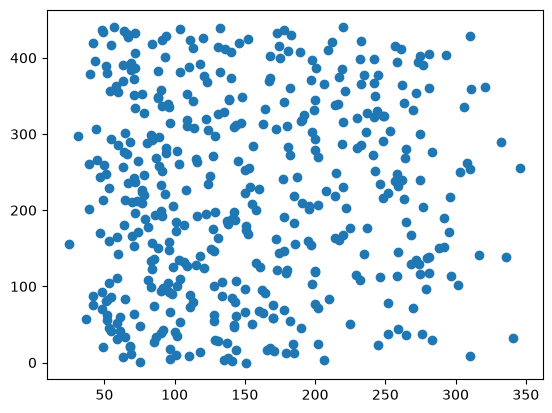

In [771]:
import matplotlib.pyplot as plt
import numpy as np


plt.scatter(df.target,np.arange(len(df.target)))

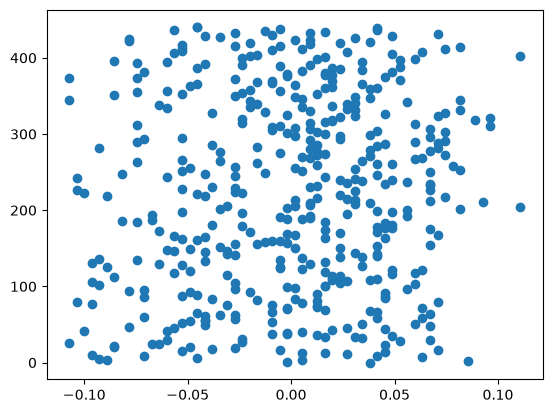

In [772]:
plt.scatter(df.age,np.arange(len(df.age)))

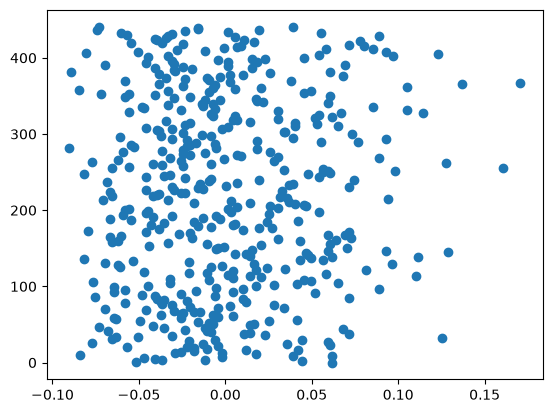

In [773]:
plt.scatter(df.bmi,np.arange(len(df.bmi)))

In [774]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [775]:
target_corr_matrix = df.corr()
target_corr_matrix =  target_corr_matrix['target']
target_corr_matrix.sort_values(ascending=False).abs()

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3        0.394789
Name: target, dtype: float64

In [776]:
X = df[['bmi','s5','bp','s4','s6','s1','age','s2','sex','s3']]
y = df.target

In [777]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [778]:
from sklearn.preprocessing import PolynomialFeatures


poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)



In [779]:
from sklearn.linear_model import LinearRegression

LR = LinearRegression()
LR.fit(X_train_poly,y_train)
print(f" Linear Regression Train Score : {LR.score(X_train_poly,y_train):.4f}")
print(f" Linear Regression Test Score : {LR.score(X_test_poly,y_test):.4f}")


 Linear Regression Train Score : 0.6081
 Linear Regression Test Score : 0.4130


In [780]:
from sklearn.linear_model import Ridge

R = Ridge(alpha=1.0)
R.fit(X_train_poly,y_train)
print(f"Ridge Train Score : {R.score(X_train_poly,y_train):.4f}")
print(f"Ridge Test Score : {R.score(X_test_poly,y_test):.4f}")

Ridge Train Score : 0.4290
Ridge Test Score : 0.4237


/Users/ahmetnuriyavuzkanat/Documents/Programming/AI/SupervisedMachineLearning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.7003130306879575e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


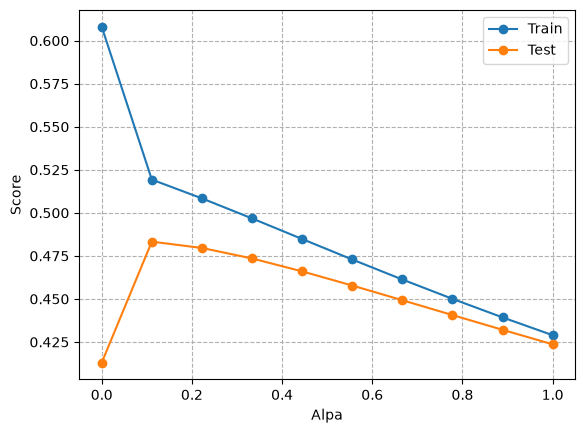

In [781]:
train_scores = []
test_scores = []
fl = np.linspace(0,1,10)



for x in fl:

    dt_model = Ridge(alpha=x)
    dt_model.fit(X_train_poly,y_train)
    tr_score = dt_model.score(X_train_poly,y_train)
    te_score = dt_model.score(X_test_poly,y_test)
    train_scores.append(tr_score)
    test_scores.append(te_score)


plt.plot(fl, train_scores, label="Train",marker="o")
plt.plot(fl, test_scores, label="Test",marker="o")
plt.ylabel("Score")
plt.xlabel("Alpa")       
plt.legend()
plt.grid(linestyle="--")